In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [2]:
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0 Safari/537.36'}
webpage = requests.get('https://www.ambitionbox.com/list-of-companies?page=1',headers=headers).text

In [3]:
soup=BeautifulSoup(webpage,'lxml')

<bound method Tag.prettify of <!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<link href="/assets/next/manifest.json" rel="manifest"/>
<style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>
<script defer="" src="/static/js/env-runtime.js"></script>
<script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>
<script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>
<title>Top Companies in India | AmbitionBox</title><meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/><meta content="1 day" data-n-head="ssr" name="revisit-after"/><meta content="Ambi
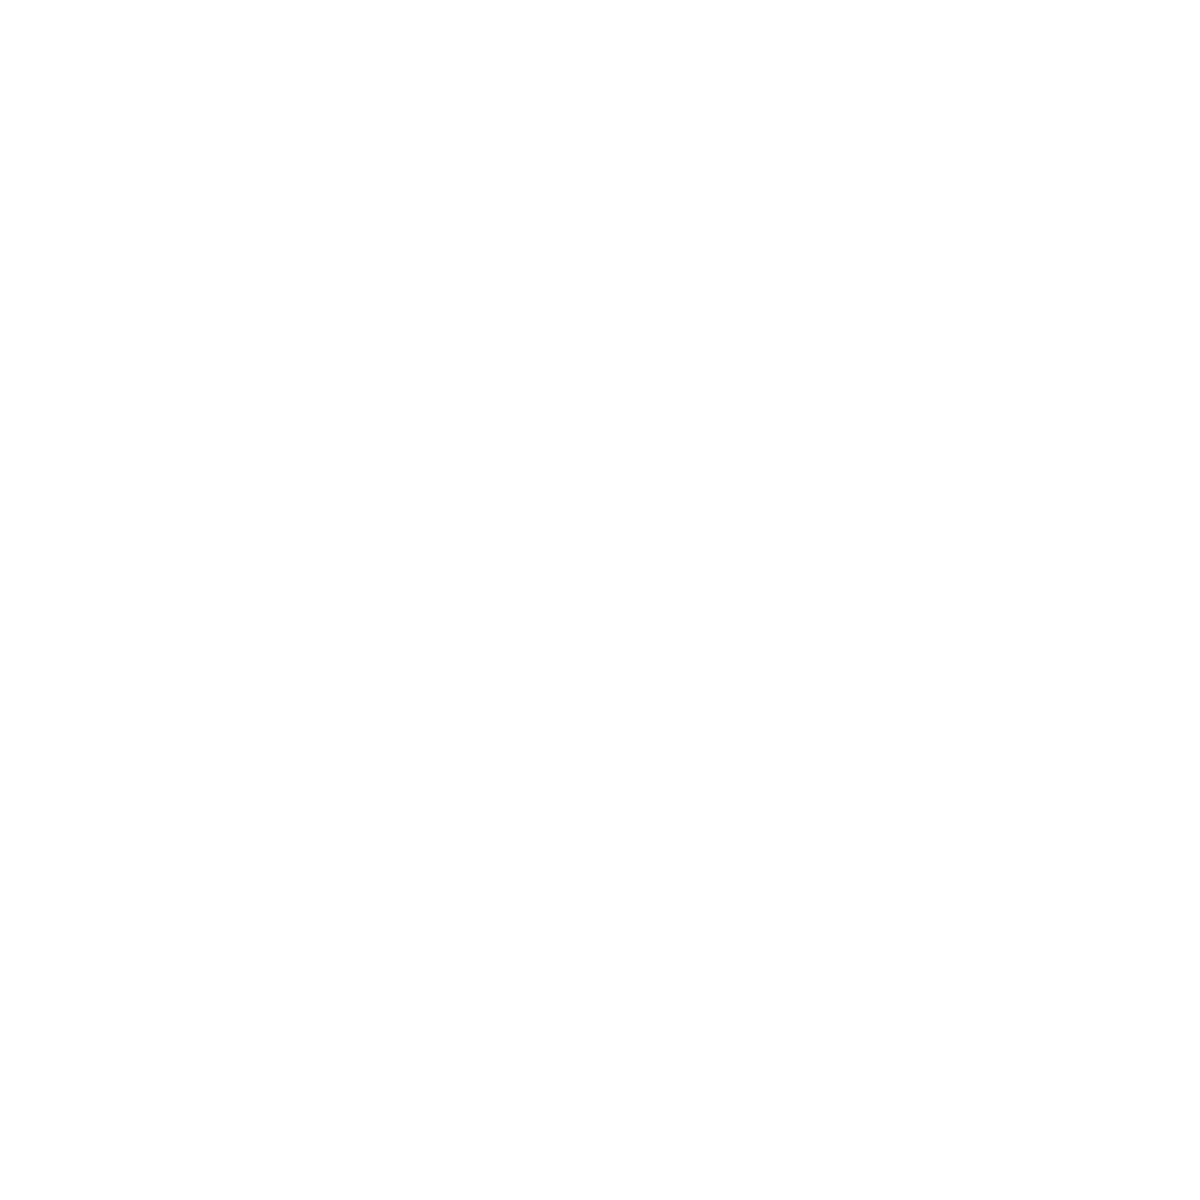

In [4]:
print(soup.prettify)

In [5]:
company=soup.find_all('div', class_='companyCardWrapper')

In [6]:
len(company)

20

In [7]:
for i in soup.find_all('h2',class_='companyCardWrapper__companyName'):
    print(i.text.strip())

TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Axis Bank
Jio
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTM Limited
HDB Financial Services


In [8]:
soup.find_all('a',class_='companyCardWrapper__ActionWrapper')

[<a class="companyCardWrapper__ActionWrapper" href="https://www.ambitionbox.com/reviews/tcs-reviews" target="_blank"><span class="companyCardWrapper__ActionCount">1.2L</span> <span class="companyCardWrapper__ActionTitle">Reviews</span></a>,
 <a class="companyCardWrapper__ActionWrapper" href="https://www.ambitionbox.com/salaries/tcs-salaries" target="_blank"><span class="companyCardWrapper__ActionCount">10.4L</span> <span class="companyCardWrapper__ActionTitle">Salaries</span></a>,
 <a class="companyCardWrapper__ActionWrapper" href="https://www.ambitionbox.com/interviews/tcs-interview-questions" target="_blank"><span class="companyCardWrapper__ActionCount">11.4k</span> <span class="companyCardWrapper__ActionTitle">Interviews</span></a>,
 <a class="companyCardWrapper__ActionWrapper" href="https://www.ambitionbox.com/jobs/tcs-jobs-cmp" target="_blank"><span class="companyCardWrapper__ActionCount">5.1k</span> <span class="companyCardWrapper__ActionTitle">Jobs</span></a>,
 <a class="company

In [9]:
list=soup.find_all('div',class_='companyCardWrapper')

In [10]:
name=[]
rating=[]
review=[]
ctype_and_Location=[]
salaries=[]
interviews=[]
Jobs=[]

for i in list:
    name.append(i.find('h2',class_='companyCardWrapper__companyName').text.strip())
    rating.append(i.find('div',class_='rating_text rating_text--md').text.strip())
    review.append(i.find('span',class_='companyCardWrapper__companyRatingCount').text.strip())
    ctype_and_Location.append(i.find('span',class_='companyCardWrapper__interLinking').text.strip())
    salaries.append(i.find('span',class_='companyCardWrapper__ActionCount').text.strip())
    interviews.append(i.find_all('span',class_='companyCardWrapper__ActionCount')[2].text.strip())
    Jobs.append(i.find_all('span',class_='companyCardWrapper__ActionCount')[3].text.strip())

d={'Name':name, 'Rating':rating, 'Review':review, 'Company_type and Location':ctype_and_Location, 'Salaries':salaries, 'Interviews':interviews, 'Jobs':Jobs }
df=pd.DataFrame(d)
df

,Name,Rating,Review,Company_type and Location,Salaries,Interviews,Jobs
0,TCS,3.3,(1.2L),IT Services & Consulting | Bengaluru +448 othe...,1.2L,11.4k,5.1k
1,Accenture,3.7,(75.3k),IT Services & Consulting | Bengaluru +261 othe...,75.3k,9.5k,20k
2,Wipro,3.6,(66.5k),IT Services & Consulting | Hyderabad +375 othe...,66.5k,6.9k,4.1k
3,Cognizant,3.7,(62.8k),IT Services & Consulting | Hyderabad +234 othe...,62.8k,6.5k,921
4,Capgemini,3.6,(54.9k),IT Services & Consulting | Bengaluru +188 othe...,54.9k,5.6k,2k
5,HDFC Bank,3.8,(54k),Banking | Mumbai +1867 other locations,54k,3.2k,242
6,Infosys,3.5,(50k),IT Services & Consulting | Bengaluru +247 othe...,50k,8.5k,3.1k
7,HCLTech,3.4,(47.1k),IT Services & Consulting | Chennai +232 other ...,47.1k,4.6k,252
8,ICICI Bank,3.9,(46.8k),Banking | Mumbai +1452 other locations,46.8k,3k,30
9,Tech Mahindra,3.3,(44.3k),IT Services & Consulting | Hyderabad +323 othe...,44.3k,4.7k,635


In [11]:
Jobs

['5.1k',
 '20k',
 '4.1k',
 '921',
 '2k',
 '242',
 '3.1k',
 '252',
 '30',
 '635',
 '507',
 '1.3k',
 '209',
 '--',
 '12',
 '76',
 '100',
 '64',
 '584',
 '4']

In [12]:
company[0].find('div', class_='companyCardWrapper__tertiaryInformation').text.strip()

'1.2L Reviews10.4L Salaries11.4k Interviews5.1k Jobs11k Benefits100 Photos'

In [13]:
final=pd.DataFrame()
for j in range(1,100):
    url='https://www.ambitionbox.com/list-of-companies?page={}'.format(j)

    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0 Safari/537.36'}
    webpage = requests.get(url,headers=headers).text
    soup=BeautifulSoup(webpage,'lxml')
    list=soup.find_all('div',class_='companyCardWrapper')
    name=[]
    rating=[]
    review=[]
    ctype_and_Location=[]
    salaries=[]
    interviews=[]
    Jobs=[]

    for i in list:
        name.append(i.find('h2',class_='companyCardWrapper__companyName').text.strip())
        rating.append(i.find('div',class_='rating_text rating_text--md').text.strip())
        review.append(i.find('span',class_='companyCardWrapper__companyRatingCount').text.strip())
        ctype_and_Location.append(i.find('span',class_='companyCardWrapper__interLinking').text.strip())
        salaries.append(i.find('span',class_='companyCardWrapper__ActionCount').text.strip())
        interviews.append(i.find_all('span',class_='companyCardWrapper__ActionCount')[2].text.strip())
        Jobs.append(i.find_all('span',class_='companyCardWrapper__ActionCount')[3].text.strip())

    d={'Name':name, 'Rating':rating, 'Review':review, 'Company_type and Location':ctype_and_Location, 'Salaries':salaries, 'Interviews':interviews, 'Jobs':Jobs }
    df=pd.DataFrame(d)
    final = pd.concat([final, df], ignore_index=True)

In [14]:
final

,Name,Rating,Review,Company_type and Location,Salaries,Interviews,Jobs
0,TCS,3.3,(1.2L),IT Services & Consulting | Bengaluru +448 othe...,1.2L,11.4k,5.1k
1,Accenture,3.7,(75.3k),IT Services & Consulting | Bengaluru +261 othe...,75.3k,9.5k,20k
2,Wipro,3.6,(66.5k),IT Services & Consulting | Hyderabad +375 othe...,66.5k,6.9k,4.1k
3,Cognizant,3.7,(62.8k),IT Services & Consulting | Hyderabad +234 othe...,62.8k,6.5k,921
4,Capgemini,3.6,(54.9k),IT Services & Consulting | Bengaluru +188 othe...,54.9k,5.6k,2k
...,...,...,...,...,...,...,...
1975,Macawber Beekay,4.2,(568),Industrial Machinery | Noida +61 other locations,568,27,27
1976,Vimta Labs,3.3,(568),Clinical Research | Hyderabad +30 other locations,568,43,5
1977,The Times of India,3.6,(568),Media & Entertainment | New Delhi +53 other lo...,568,47,1
1978,GSPANN Technologies,4.0,(568),IT Services & Consulting | Hyderabad +9 other ...,568,53,63


In [15]:
final.to_excel("companies_data.xlsx", index=False)

In [16]:
final.to_csv('final.csv', index=False)